# 05 — Evaluación y selección de modelos

## Objetivo

Este notebook compara los resultados obtenidos mediante backtesting para las
tres familias de modelos consideradas:

- **Desarrollo**
- **GLM**
- **Machine Learning**

El objetivo es seleccionar una especificación para cada escenario de desarrollo:

- creciente;
- decreciente;
- mixto.

La comparación se realiza sobre las predicciones históricas generadas bajo el
mismo diseño experimental, por lo que los métodos se evalúan sobre un universo
común y comparable.

La selección no se basa únicamente en el menor error promedio. También se
consideran:

1. **MAE**, como medida principal de error absoluto;
2. **RMSE**, para penalizar errores de mayor magnitud;
3. **MAPE**, como medida relativa de error;
4. **bias y relative bias**, para detectar sobreestimación o subestimación
   sistemática;
5. **estabilidad entre valuaciones**;
6. **comportamiento según la edad de desarrollo**.

El análisis por edad resulta especialmente importante porque el backtesting
cronológico no permite evaluar todas las edades jóvenes con la misma cobertura.
Por ello, las conclusiones deben interpretarse dentro del universo efectivamente
observable en cada escenario.

## Configuración del análisis

Se importan las librerías utilizadas y se definen las rutas de las salidas persistidas del backtesting.


In [58]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BACKTEST_RESULTS_DIR = (
    PROJECT_ROOT / "data" / "processed" / "backtesting"
)

PREDICTIONS_PATH = (
    BACKTEST_RESULTS_DIR / "evaluated_predictions.parquet"
)

METRICS_PATH = (
    BACKTEST_RESULTS_DIR / "valuation_metrics.parquet"
)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Resultados:   {BACKTEST_RESULTS_DIR}")

PROJECT_ROOT: c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales
Resultados:   c:\Users\derec\Desktop\Proyectos\Modelado_Reservas_ML_vs_metodos_Actuariales\data\processed\backtesting


## 1. Carga de resultados del backtesting

Se utilizan directamente las salidas persistidas por el notebook
`04_backtesting.ipynb`.

De esta forma, este notebook no reentrena modelos ni reconstruye snapshots.
Su responsabilidad se limita a la comparación, evaluación y selección de las
alternativas previamente evaluadas.

In [59]:
evaluated_predictions = pd.read_parquet(PREDICTIONS_PATH)
valuation_metrics = pd.read_parquet(METRICS_PATH)

print(
    f"Predicciones evaluadas: {len(evaluated_predictions):,}"
)

print(
    f"Registros de métricas:  {len(valuation_metrics):,}"
)

print(
    f"Métodos:                "
    f"{evaluated_predictions['method_name'].nunique()}"
)

print(
    f"Escenarios:              "
    f"{evaluated_predictions['scenario'].nunique()}"
)

Predicciones evaluadas: 287,976
Registros de métricas:  5,538
Métodos:                26
Escenarios:              3


## 2. Catálogo de modelos

Antes de comparar el desempeño se construye un catálogo de las alternativas
evaluadas.

Cada `method_name` debe pertenecer de forma unívoca a una familia metodológica.
Esta relación permitirá integrar las métricas por valuación con la clasificación
de los modelos en Desarrollo, GLM y Machine Learning.

In [60]:
method_catalog = (
    evaluated_predictions[
        ["method_name", "method_family"]
    ]
    .drop_duplicates()
    .sort_values(
        ["method_family", "method_name"]
    )
    .reset_index(drop=True)
)

# Cada método debe pertenecer a una sola familia
assert (
    method_catalog
    .groupby("method_name")["method_family"]
    .nunique()
    .max()
    == 1
)

print(
    method_catalog["method_family"]
    .value_counts()
)

display(method_catalog)

method_family
development         21
machine_learning     3
glm                  2
Name: count, dtype: int64


,method_name,method_family
0,M_24_minmax,development
1,M_24_none,development
2,M_24_std2,development
3,M_all_minmax,development
4,M_all_none,development
5,M_all_std2,development
6,S_24_minmax,development
7,S_24_none,development
8,S_24_std2,development
9,S_all_minmax,development


### 2.1 Integración de la familia metodológica

La familia metodológica se incorpora a la tabla de métricas por valuación para mantener una clasificación consistente en los análisis posteriores.


In [61]:
valuation_metrics = valuation_metrics.merge(
    method_catalog,
    on="method_name",
    how="left",
    validate="many_to_one",
)

assert valuation_metrics["method_family"].notna().all()

print(valuation_metrics.shape)

display(
    valuation_metrics.head()
)

(5538, 10)


,scenario,model_valuation_period,method_name,n_predictions,mae,rmse,mape,bias,relative_bias,method_family
0,creciente,2020-01,M_24_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development
1,creciente,2020-01,M_24_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development
2,creciente,2020-01,M_24_std2,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development
3,creciente,2020-01,M_all_minmax,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development
4,creciente,2020-01,M_all_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development


## 3. Cobertura del backtesting

La comparación de modelos debe interpretarse considerando la cobertura temporal
del experimento.

Una predicción solo puede evaluarse cuando el valor objetivo correspondiente a
`dev_M` ya se ha revelado dentro del horizonte disponible. Como consecuencia,
las edades de desarrollo más jóvenes no necesariamente están representadas en
el backtesting con la misma cobertura que las edades más avanzadas.

Antes de comparar los modelos se resume el universo efectivo de evaluación por
escenario.

In [62]:
coverage = (
    evaluated_predictions
    .groupby("scenario")
    .agg(
        n_predictions=("prediction", "size"),
        n_methods=("method_name", "nunique"),
        n_valuations=("valuation_period", "nunique"),
        n_accident_periods=("accident_period", "nunique"),
        min_dev_month=("snapshot_dev_month", "min"),
        max_dev_month=("snapshot_dev_month", "max"),
    )
    .reset_index()
)

display(coverage)

,scenario,n_predictions,n_methods,n_valuations,n_accident_periods,min_dev_month,max_dev_month
0,creciente,110760,26,71,130,0,59
1,decreciente,88608,26,71,118,0,47
2,mixto,88608,26,71,118,0,47


### 3.1 Universo efectivo de evaluación

Se identifica el número de casos únicos evaluables por escenario, separándolo del número total de predicciones generado por los 26 métodos.


In [63]:
evaluation_keys = [
    "scenario",
    "valuation_period",
    "accident_period",
]

evaluation_universe = (
    evaluated_predictions[evaluation_keys]
    .drop_duplicates()
)

coverage_universe = (
    evaluation_universe
    .groupby("scenario")
    .agg(
        n_evaluable_cases=("accident_period", "size"),
        n_valuations=("valuation_period", "nunique"),
        n_accident_periods=("accident_period", "nunique"),
    )
    .reset_index()
)

display(coverage_universe)

,scenario,n_evaluable_cases,n_valuations,n_accident_periods
0,creciente,4260,71,130
1,decreciente,3408,71,118
2,mixto,3408,71,118


## 4. Comparación global de desempeño

La primera etapa de selección compara los 26 métodos sobre el universo completo
de predicciones evaluables de cada escenario.

Las métricas se recalculan directamente a partir de las predicciones individuales,
de forma que cada combinación escenario–valuación–cohorte tenga el mismo peso
dentro de la evaluación global.

Se consideran:

- **MAE:** magnitud promedio del error absoluto.
- **RMSE:** penaliza con mayor intensidad los errores grandes.
- **MAPE:** expresa el error absoluto relativo al valor objetivo.
- **Bias:** indica la dirección promedio del error.
- **Relative bias:** expresa dicho sesgo en términos relativos.

MAE se utiliza como referencia principal de precisión, mientras que las métricas
restantes permiten evaluar robustez y posibles errores sistemáticos.

In [64]:
def compute_global_metrics(group):
    error = group["prediction"] - group["target_amount"]

    return pd.Series(
        {
            "n_predictions": len(group),
            "mae": np.mean(np.abs(error)),
            "rmse": np.sqrt(np.mean(error**2)),
            "mape": np.mean(
                np.abs(error) / group["target_amount"]
            ),
            "bias": np.mean(error),
            "relative_bias": (
                np.sum(error)
                / np.sum(group["target_amount"])
            ),
        }
    )


global_metrics = (
    evaluated_predictions
    .groupby(
        ["scenario", "method_family", "method_name"],
        as_index=False,
    )
    .apply(
        compute_global_metrics,
        include_groups=False,
    )
    .reset_index(drop=True)
)

print(global_metrics.shape)

display(global_metrics.head())

(78, 9)


,scenario,method_family,method_name,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,development,M_24_minmax,4260.0,20476.588290,25945.423256,0.016601,-190.020886,-0.000154
1,creciente,development,M_24_none,4260.0,20476.588290,25945.423256,0.016601,-190.020886,-0.000154
2,creciente,development,M_24_std2,4260.0,22155.700640,27872.426109,0.017984,1887.857206,0.001528
3,creciente,development,M_all_minmax,4260.0,19246.985372,24382.172553,0.015672,-4458.573418,-0.003608
4,creciente,development,M_all_none,4260.0,19246.985372,24382.172553,0.015672,-4458.573418,-0.003608


### 4.1 Ranking exploratorio por MAE y RMSE

El ranking se utiliza únicamente como herramienta descriptiva inicial; la selección final incorpora criterios adicionales de estabilidad y razonabilidad actuarial.


In [65]:
global_metrics["mae_rank"] = (
    global_metrics
    .groupby("scenario")["mae"]
    .rank(method="min")
    .astype(int)
)

global_metrics["rmse_rank"] = (
    global_metrics
    .groupby("scenario")["rmse"]
    .rank(method="min")
    .astype(int)
)

In [66]:
comparison = (
    global_metrics
    .sort_values(
        ["scenario", "mae"]
    )
    .reset_index(drop=True)
)

display(
    comparison[
        [
            "scenario",
            "method_family",
            "method_name",
            "n_predictions",
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
            "mae_rank",
            "rmse_rank",
        ]
    ]
)

,scenario,method_family,method_name,n_predictions,mae,rmse,mape,bias,relative_bias,mae_rank,rmse_rank
0,creciente,development,VW_all_none,4260.0,15384.030001,19484.983876,0.012463,155.155935,0.000126,1,1
1,creciente,development,VW_36_none,4260.0,15411.590649,19512.752284,0.012483,85.676738,0.000069,2,2
2,creciente,development,VW_24_none,4260.0,15497.523122,19604.998612,0.012549,8.485487,0.000007,3,3
3,creciente,development,VW_12_none,4260.0,15723.347750,19893.428660,0.012729,7.435887,0.000006,4,4
4,creciente,development,VW_6_none,4260.0,16250.231838,20557.809792,0.013159,27.689880,0.000022,5,5
...,...,...,...,...,...,...,...,...,...,...,...
73,mixto,glm,GLM_gamma_log,3408.0,92406.876020,119411.203964,0.072728,-35131.118252,-0.027650,22,22
74,mixto,machine_learning,ML_ridge,3408.0,93370.744815,121787.640175,0.073109,-45906.898376,-0.036131,23,23
75,mixto,glm,GLM_gaussian_identity,3408.0,93407.971141,121862.604277,0.073144,-45918.275077,-0.036140,24,24
76,mixto,machine_learning,ML_hist_gradient_boosting,3408.0,99475.950706,133854.695997,0.075941,-74640.035065,-0.058746,25,25


## 5. Preselección por familia metodológica

Antes de realizar la selección final se identifica la alternativa con menor MAE
dentro de cada familia metodológica y escenario.

Esta etapa reduce el conjunto de candidatos sin mezclar todavía las diferencias
entre Desarrollo, GLM y Machine Learning.

La preselección utiliza MAE como criterio principal. Posteriormente, los
candidatos se comparan mediante RMSE, MAPE, sesgo, estabilidad temporal y
comportamiento por edad de desarrollo.

In [67]:
family_candidates = (
    global_metrics
    .sort_values(
        [
            "scenario",
            "method_family",
            "mae",
        ]
    )
    .groupby(
        ["scenario", "method_family"],
        as_index=False,
    )
    .first()
)

family_candidates = (
    family_candidates
    .sort_values(
        ["scenario", "mae"]
    )
    .reset_index(drop=True)
)

display(
    family_candidates[
        [
            "scenario",
            "method_family",
            "method_name",
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
        ]
    ]
)

,scenario,method_family,method_name,mae,rmse,mape,bias,relative_bias
0,creciente,development,VW_all_none,15384.030001,19484.983876,0.012463,155.155935,0.000126
1,creciente,machine_learning,ML_ridge,63425.800022,125948.605877,0.052756,3038.214235,0.002459
2,creciente,glm,GLM_gaussian_identity,65398.972112,144127.230615,0.054611,5168.231406,0.004183
3,decreciente,development,VW_all_none,15177.160022,19230.339915,0.012043,-538.223186,-0.000428
4,decreciente,glm,GLM_gaussian_identity,29505.209639,37711.144397,0.023282,-1420.284204,-0.001130
5,decreciente,machine_learning,ML_ridge,29536.810929,37737.767670,0.023310,-1486.831926,-0.001183
6,mixto,development,VW_all_none,15519.108462,19550.051073,0.012216,-83.383930,-0.000066
7,mixto,glm,GLM_gamma_log,92406.876020,119411.203964,0.072728,-35131.118252,-0.027650
8,mixto,machine_learning,ML_ridge,93370.744815,121787.640175,0.073109,-45906.898376,-0.036131


### 5.1 Comparación relativa frente a Desarrollo

Se cuantifica el cambio porcentual del MAE de GLM y Machine Learning respecto al mejor método de Desarrollo de cada escenario.


In [68]:
development_reference = (
    family_candidates[
        family_candidates["method_family"] == "development"
    ][
        ["scenario", "mae"]
    ]
    .rename(
        columns={"mae": "development_mae"}
    )
)

family_candidates = family_candidates.merge(
    development_reference,
    on="scenario",
    how="left",
    validate="many_to_one",
)

family_candidates["mae_change_vs_development"] = (
    (
        family_candidates["mae"]
        / family_candidates["development_mae"]
    )
    - 1
)

family_candidates["mae_change_vs_development_pct"] = (
    100
    * family_candidates["mae_change_vs_development"]
)

display(
    family_candidates[
        [
            "scenario",
            "method_family",
            "method_name",
            "mae",
            "rmse",
            "mape",
            "relative_bias",
            "mae_change_vs_development_pct",
        ]
    ]
)

,scenario,method_family,method_name,mae,rmse,mape,relative_bias,mae_change_vs_development_pct
0,creciente,development,VW_all_none,15384.030001,19484.983876,0.012463,0.000126,0.000000
1,creciente,machine_learning,ML_ridge,63425.800022,125948.605877,0.052756,0.002459,312.283388
2,creciente,glm,GLM_gaussian_identity,65398.972112,144127.230615,0.054611,0.004183,325.109494
3,decreciente,development,VW_all_none,15177.160022,19230.339915,0.012043,-0.000428,0.000000
4,decreciente,glm,GLM_gaussian_identity,29505.209639,37711.144397,0.023282,-0.001130,94.405341
5,decreciente,machine_learning,ML_ridge,29536.810929,37737.767670,0.023310,-0.001183,94.613557
6,mixto,development,VW_all_none,15519.108462,19550.051073,0.012216,-0.000066,0.000000
7,mixto,glm,GLM_gamma_log,92406.876020,119411.203964,0.072728,-0.027650,495.439334
8,mixto,machine_learning,ML_ridge,93370.744815,121787.640175,0.073109,-0.036131,501.650185


### 5.2 Comparación visual de los candidatos

La siguiente figura resume el MAE de los mejores representantes de cada familia. Su propósito es mostrar la magnitud de las diferencias antes de analizar dónde se originan.


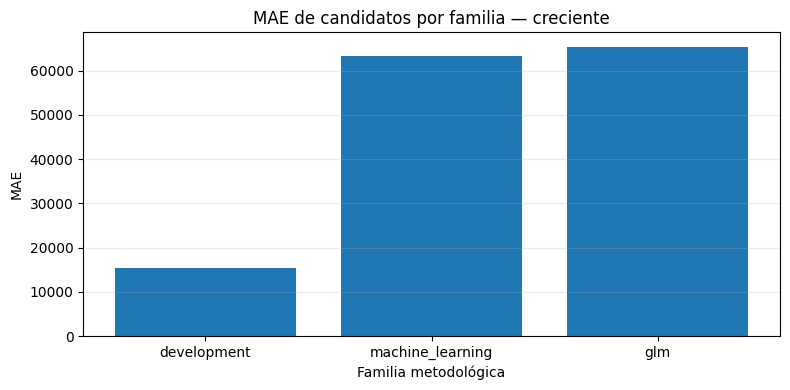

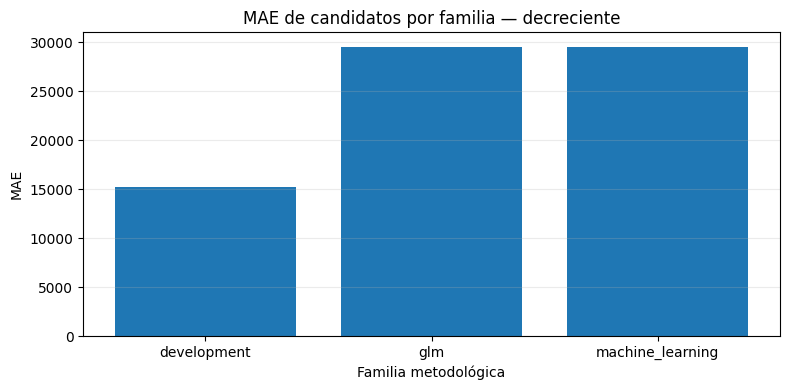

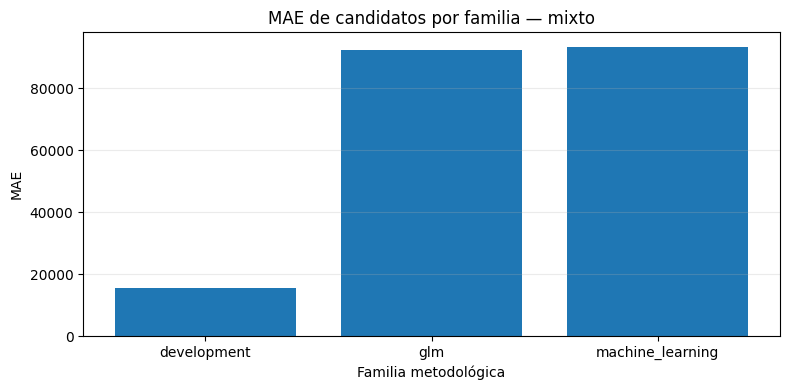

In [69]:
for scenario in scenarios if "scenarios" in globals() else ["creciente", "decreciente", "mixto"]:
    plot_data = (
        family_candidates[family_candidates["scenario"] == scenario]
        .sort_values("mae")
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(plot_data["method_family"], plot_data["mae"])
    ax.set_title(f"MAE de candidatos por familia — {scenario}")
    ax.set_xlabel("Familia metodológica")
    ax.set_ylabel("MAE")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 6. Diagnóstico del error por edad de desarrollo

La comparación global muestra una diferencia considerable entre el método de
Desarrollo y los modelos GLM y Machine Learning.

Antes de interpretar esta diferencia como evidencia de superioridad de una
familia, se analiza dónde se originan los errores.

La edad de desarrollo es especialmente relevante porque determina cuánta
información acumulada se encuentra disponible al momento de realizar la
predicción. En edades jóvenes existe mayor incertidumbre y una mayor proporción
del desarrollo permanece sin observar.

Para facilitar la interpretación, las edades se agrupan en intervalos de
seis meses y se comparan MAE, RMSE, MAPE y sesgo relativo.

In [70]:
# ============================================================
# BANDAS DE EDAD DE DESARROLLO
# ============================================================

evaluated_predictions = evaluated_predictions.copy()

max_dev = int(
    evaluated_predictions["snapshot_dev_month"].max()
)

bins = list(range(0, max_dev + 7, 6))

evaluated_predictions["dev_band"] = pd.cut(
    evaluated_predictions["snapshot_dev_month"],
    bins=bins,
    right=False,
    include_lowest=True,
)

print(
    evaluated_predictions[
        ["snapshot_dev_month", "dev_band"]
    ]
    .drop_duplicates()
    .sort_values("snapshot_dev_month")
    .head(20)
)

    snapshot_dev_month  dev_band
59                   0    [0, 6)
58                   1    [0, 6)
57                   2    [0, 6)
56                   3    [0, 6)
55                   4    [0, 6)
54                   5    [0, 6)
53                   6   [6, 12)
52                   7   [6, 12)
51                   8   [6, 12)
50                   9   [6, 12)
49                  10   [6, 12)
48                  11   [6, 12)
47                  12  [12, 18)
46                  13  [12, 18)
45                  14  [12, 18)
44                  15  [12, 18)
43                  16  [12, 18)
42                  17  [12, 18)
41                  18  [18, 24)
40                  19  [18, 24)


### 6.1 Métricas por banda de desarrollo

Las métricas se recalculan por intervalos de seis meses para localizar en qué edades se concentra la diferencia de desempeño.


In [71]:
age_metrics = (
    evaluated_predictions
    .groupby(
        [
            "scenario",
            "method_family",
            "method_name",
            "dev_band",
        ],
        observed=True,
    )
    .apply(
        compute_global_metrics,
        include_groups=False,
    )
    .reset_index()
)

display(age_metrics.head())

,scenario,method_family,method_name,dev_band,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,development,M_24_minmax,"[0, 6)",426.0,22499.359301,28914.301619,0.016799,7452.198949,0.005546
1,creciente,development,M_24_minmax,"[6, 12)",426.0,20773.373749,26990.815404,0.015839,-2544.573401,-0.001942
2,creciente,development,M_24_minmax,"[12, 18)",426.0,21449.998465,27699.162174,0.016697,6731.705115,0.005232
3,creciente,development,M_24_minmax,"[18, 24)",426.0,21435.607294,26996.787648,0.017015,9662.397405,0.007647
4,creciente,development,M_24_minmax,"[24, 30)",426.0,20017.079263,24927.216390,0.016134,4148.113380,0.003336


### 6.2 Candidatos por familia

A partir de la preselección anterior se conservan los mejores representantes de Desarrollo, GLM y Machine Learning para los diagnósticos detallados.


In [72]:
candidate_keys = (
    family_candidates[
        [
            "scenario",
            "method_family",
            "method_name",
        ]
    ]
    .drop_duplicates()
)

candidate_age_metrics = age_metrics.merge(
    candidate_keys,
    on=[
        "scenario",
        "method_family",
        "method_name",
    ],
    how="inner",
    validate="many_to_one",
)

print(candidate_age_metrics.shape)

display(candidate_age_metrics)

(78, 10)


,scenario,method_family,method_name,dev_band,n_predictions,mae,rmse,mape,bias,relative_bias
0,creciente,development,VW_all_none,"[0, 6)",426.0,16775.149049,21394.824199,0.012589,628.849565,0.000468
1,creciente,development,VW_all_none,"[6, 12)",426.0,16838.777258,21298.503884,0.012726,-3167.436104,-0.002418
2,creciente,development,VW_all_none,"[12, 18)",426.0,15845.729126,20248.772996,0.012289,1606.548949,0.001249
3,creciente,development,VW_all_none,"[18, 24)",426.0,15770.525809,19804.744173,0.012474,2107.361837,0.001668
4,creciente,development,VW_all_none,"[24, 30)",426.0,14996.996159,18946.831113,0.012132,1173.845673,0.000944
...,...,...,...,...,...,...,...,...,...,...
73,mixto,machine_learning,ML_ridge,"[18, 24)",426.0,89871.251659,112625.947278,0.072413,-5293.399437,-0.004148
74,mixto,machine_learning,ML_ridge,"[24, 30)",426.0,77055.864805,97816.736577,0.062667,-16594.309322,-0.013132
75,mixto,machine_learning,ML_ridge,"[30, 36)",426.0,75451.918853,92421.095724,0.061625,-30739.735480,-0.024811
76,mixto,machine_learning,ML_ridge,"[36, 42)",426.0,70787.033217,86125.414866,0.057884,-33336.088517,-0.027519


### 6.3 MAE por edad de desarrollo


In [73]:
mae_by_age = (
    candidate_age_metrics
    .pivot_table(
        index=["scenario", "dev_band"],
        columns="method_family",
        values="mae",
    )
    .reset_index()
)

display(mae_by_age)

C:\Users\derec\AppData\Local\Temp\ipykernel_12424\176873151.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


method_family,scenario,dev_band,development,glm,machine_learning
0,creciente,"[0, 6)",16775.149049,119781.864081,118795.262564
1,creciente,"[6, 12)",16838.777258,84169.579206,81282.820719
2,creciente,"[12, 18)",15845.729126,51796.340507,50988.391508
3,creciente,"[18, 24)",15770.525809,74356.993767,71570.723535
4,creciente,"[24, 30)",14996.996159,56442.337121,55566.584792
5,creciente,"[30, 36)",14220.306357,71769.919214,68818.763794
6,creciente,"[36, 42)",15842.702380,41828.965717,40856.050968
7,creciente,"[42, 48)",14657.114871,54932.963996,51867.637927
8,creciente,"[48, 54)",14586.995359,34201.484731,33193.410290
9,creciente,"[54, 60)",14306.003639,64709.272776,61318.354124


In [74]:
mae_by_age["glm_vs_development"] = (
    mae_by_age["glm"]
    / mae_by_age["development"]
)

mae_by_age["ml_vs_development"] = (
    mae_by_age["machine_learning"]
    / mae_by_age["development"]
)

display(mae_by_age)

method_family,scenario,dev_band,development,glm,machine_learning,glm_vs_development,ml_vs_development
0,creciente,"[0, 6)",16775.149049,119781.864081,118795.262564,7.140435,7.081622
1,creciente,"[6, 12)",16838.777258,84169.579206,81282.820719,4.998556,4.827121
2,creciente,"[12, 18)",15845.729126,51796.340507,50988.391508,3.268789,3.217800
3,creciente,"[18, 24)",15770.525809,74356.993767,71570.723535,4.714934,4.538259
4,creciente,"[24, 30)",14996.996159,56442.337121,55566.584792,3.763576,3.705181
5,creciente,"[30, 36)",14220.306357,71769.919214,68818.763794,5.047002,4.839471
6,creciente,"[36, 42)",15842.702380,41828.965717,40856.050968,2.640267,2.578856
7,creciente,"[42, 48)",14657.114871,54932.963996,51867.637927,3.747870,3.538734
8,creciente,"[48, 54)",14586.995359,34201.484731,33193.410290,2.344656,2.275548
9,creciente,"[54, 60)",14306.003639,64709.272776,61318.354124,4.523225,4.286197


### 6.4 Calibración por edad: razón predicción/objetivo


In [75]:
candidate_predictions = evaluated_predictions.merge(
    candidate_keys,
    on=[
        "scenario",
        "method_family",
        "method_name",
    ],
    how="inner",
    validate="many_to_one",
)

candidate_predictions["prediction_ratio"] = (
    candidate_predictions["prediction"]
    / candidate_predictions["target_amount"]
)

In [76]:
ratio_by_age = (
    candidate_predictions
    .groupby(
        [
            "scenario",
            "method_family",
            "dev_band",
        ],
        observed=True,
    )
    .agg(
        n=("prediction_ratio", "size"),
        mean_ratio=("prediction_ratio", "mean"),
        median_ratio=("prediction_ratio", "median"),
        q05=("prediction_ratio", lambda x: x.quantile(0.05)),
        q95=("prediction_ratio", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

display(ratio_by_age)

,scenario,method_family,dev_band,n,mean_ratio,median_ratio,q05,q95
0,creciente,development,"[0, 6)",426,1.000480,1.000004,0.973964,1.027907
1,creciente,development,"[6, 12)",426,0.997502,0.997241,0.972887,1.022845
2,creciente,development,"[12, 18)",426,1.001197,1.000236,0.977246,1.026643
3,creciente,development,"[18, 24)",426,1.001640,1.001503,0.975992,1.027095
4,creciente,development,"[24, 30)",426,1.000990,1.001385,0.976554,1.026709
...,...,...,...,...,...,...,...,...
73,mixto,machine_learning,"[18, 24)",426,0.998582,1.003250,0.836207,1.131470
74,mixto,machine_learning,"[24, 30)",426,0.989227,0.989375,0.855602,1.110636
75,mixto,machine_learning,"[30, 36)",426,0.977794,0.973194,0.864410,1.087944
76,mixto,machine_learning,"[36, 42)",426,0.975921,0.968987,0.878936,1.071583


### 6.5 Perfil del error por edad de desarrollo

La visualización permite comprobar si la ventaja de una familia se concentra en edades específicas o se mantiene a lo largo del desarrollo.


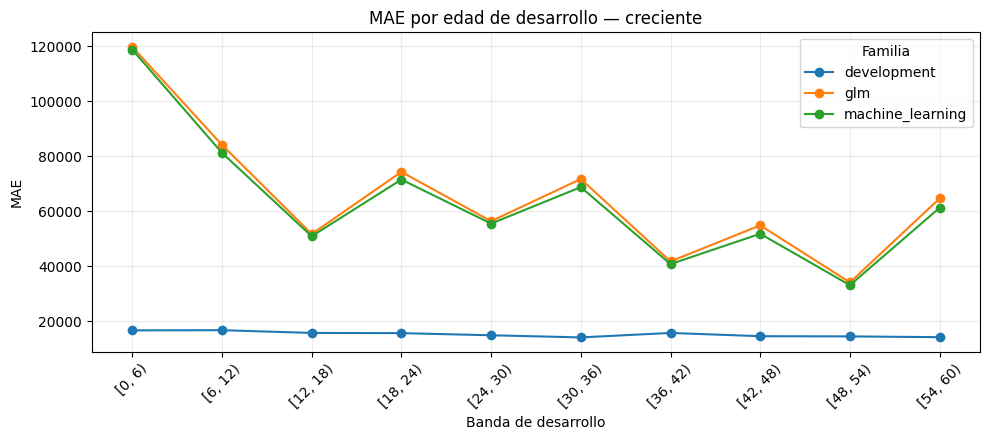

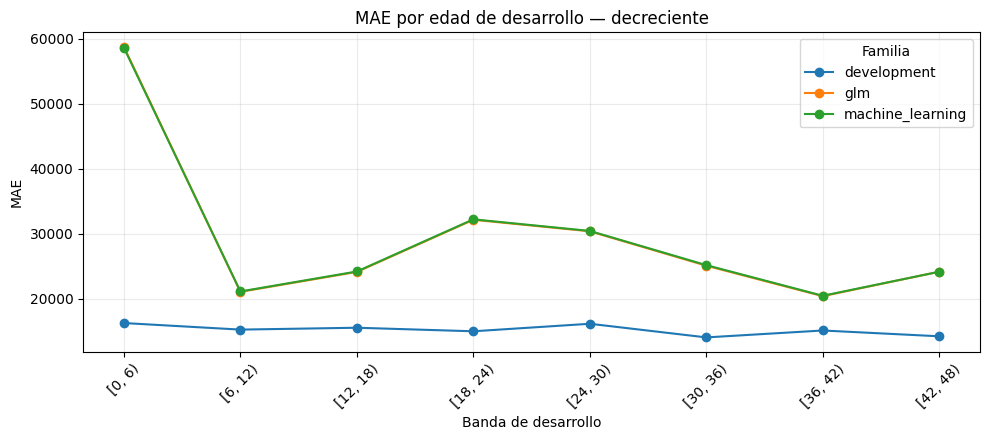

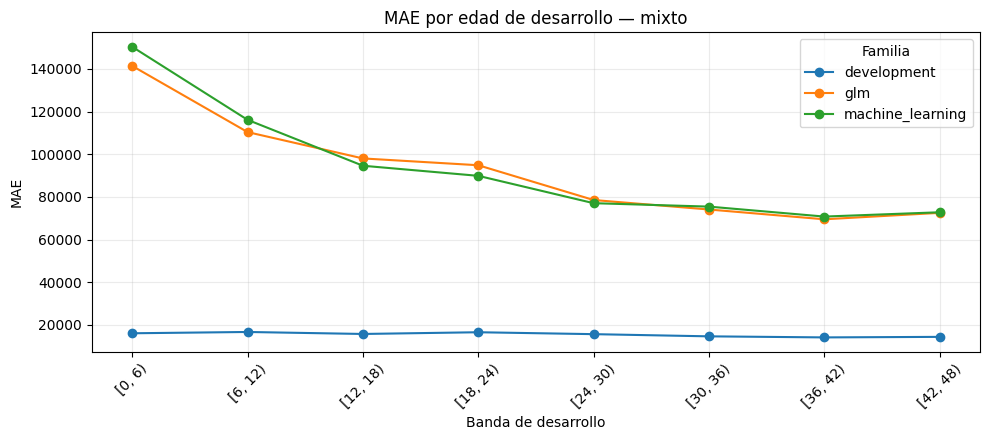

In [77]:
for scenario in ["creciente", "decreciente", "mixto"]:
    plot_data = candidate_age_metrics[candidate_age_metrics["scenario"] == scenario].copy()
    plot_data["dev_band_label"] = plot_data["dev_band"].astype(str)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    for family, group in plot_data.groupby("method_family"):
        group = group.sort_values("dev_band")
        ax.plot(group["dev_band_label"], group["mae"], marker="o", label=family)

    ax.set_title(f"MAE por edad de desarrollo — {scenario}")
    ax.set_xlabel("Banda de desarrollo")
    ax.set_ylabel("MAE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25)
    ax.legend(title="Familia")
    plt.tight_layout()
    plt.show()


## 7. Estabilidad temporal de los modelos candidatos

El desempeño agregado no permite identificar si un modelo mantiene un
comportamiento consistente a través del tiempo.

Por ello, los mejores representantes de cada familia se evalúan también a nivel
de valuación histórica.

Un modelo estable debería presentar:

- errores relativamente consistentes entre valuaciones;
- ausencia de períodos con deterioros extremos recurrentes;
- sesgo temporal controlado;
- comportamiento coherente entre las distintas fechas de evaluación.

Este análisis complementa las métricas globales y permite distinguir entre un
buen desempeño promedio y un desempeño robusto a través del tiempo.

In [78]:
candidate_valuation_metrics = valuation_metrics.merge(
    candidate_keys,
    on=[
        "scenario",
        "method_family",
        "method_name",
    ],
    how="inner",
    validate="many_to_one",
)

print(candidate_valuation_metrics.shape)

display(candidate_valuation_metrics.head())

(639, 10)


,scenario,model_valuation_period,method_name,n_predictions,mae,rmse,mape,bias,relative_bias,method_family
0,creciente,2020-01,VW_all_none,60,17781.327717,24137.005544,0.015912,407.073231,0.000423,development
1,creciente,2020-02,VW_all_none,60,16902.930625,20142.991536,0.015342,-1731.149011,-0.001699,development
2,creciente,2020-03,VW_all_none,60,15997.070442,20152.659811,0.014319,-5149.462101,-0.004498,development
3,creciente,2020-04,VW_all_none,60,14318.527039,17673.074561,0.012963,7.930530,0.000029,development
4,creciente,2020-05,VW_all_none,60,13885.855461,17911.484214,0.012539,3126.034642,0.002698,development


### 7.1 Resumen de estabilidad


In [79]:
stability_summary = (
    candidate_valuation_metrics
    .groupby(
        [
            "scenario",
            "method_family",
            "method_name",
        ]
    )
    .agg(
        n_valuations=("model_valuation_period", "nunique"),

        mean_mae=("mae", "mean"),
        median_mae=("mae", "median"),
        std_mae=("mae", "std"),

        q05_mae=("mae", lambda x: x.quantile(0.05)),
        q95_mae=("mae", lambda x: x.quantile(0.95)),

        max_mae=("mae", "max"),

        mean_relative_bias=("relative_bias", "mean"),
        max_abs_relative_bias=(
            "relative_bias",
            lambda x: np.abs(x).max(),
        ),
    )
    .reset_index()
)

stability_summary["cv_mae"] = (
    stability_summary["std_mae"]
    / stability_summary["mean_mae"]
)

display(
    stability_summary.sort_values(
        ["scenario", "mean_mae"]
    )
)

,scenario,method_family,method_name,n_valuations,mean_mae,median_mae,std_mae,q05_mae,q95_mae,max_mae,mean_relative_bias,max_abs_relative_bias,cv_mae
0,creciente,development,VW_all_none,71,15384.030001,15446.843397,1679.029393,12907.062172,18031.438653,18980.599372,0.000115,0.004620,0.109141
2,creciente,machine_learning,ML_ridge,71,63425.800022,48721.334082,76677.397972,41167.961307,113625.717056,676112.205400,0.005940,0.586902,1.208931
1,creciente,glm,GLM_gaussian_identity,71,65398.972112,48742.730247,93599.817594,41189.114449,112340.589538,823402.329548,0.007927,0.720843,1.431212
3,decreciente,development,VW_all_none,71,15177.160022,15005.236436,1937.809774,11555.235903,18099.891794,19054.553288,-0.000430,0.004676,0.127679
4,decreciente,glm,GLM_gaussian_identity,71,29505.209639,29279.537889,2668.084789,25661.666704,33917.229576,37073.673703,-0.000455,0.023228,0.090428
5,decreciente,machine_learning,ML_ridge,71,29536.810929,29285.550311,2679.663002,25716.939957,33930.642282,37398.387995,-0.000502,0.023729,0.090723
6,mixto,development,VW_all_none,71,15519.108462,15271.686034,1980.627581,12773.116151,19378.258942,21089.810442,-0.000070,0.004339,0.127625
7,mixto,glm,GLM_gamma_log,71,92406.876020,81817.000548,35438.585813,67226.582022,158030.033357,282826.294671,-0.024760,0.242509,0.383506
8,mixto,machine_learning,ML_ridge,71,93370.744815,83848.587466,37115.494013,67728.400439,156147.072165,302777.024935,-0.032410,0.260323,0.397507


### 7.2 Evolución del MAE entre fechas de valoración


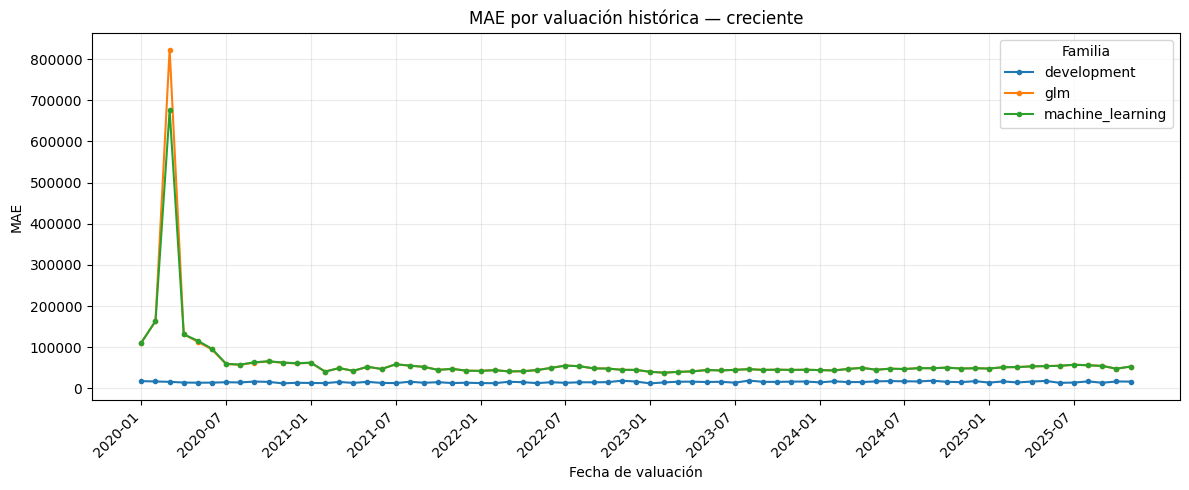

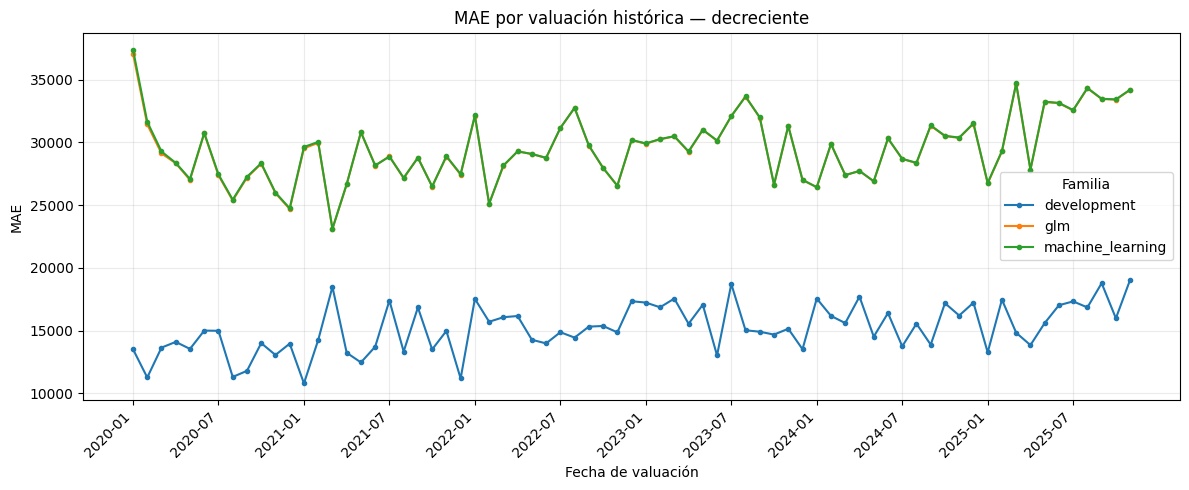

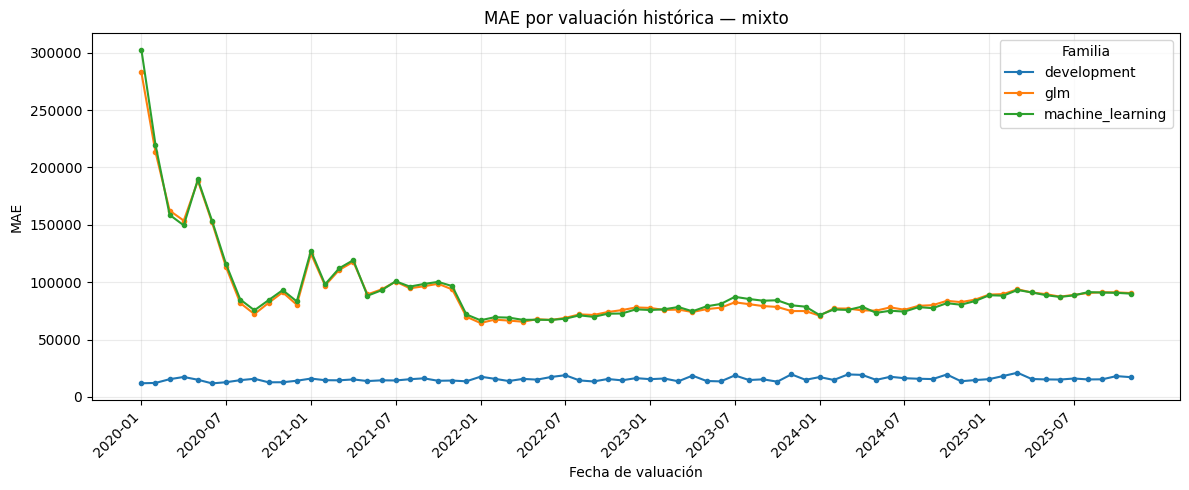

In [80]:
scenarios = [
    "creciente",
    "decreciente",
    "mixto",
]

for scenario in scenarios:

    plot_data = (
        candidate_valuation_metrics[
            candidate_valuation_metrics["scenario"]
            == scenario
        ]
        .sort_values("model_valuation_period")
    )

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    for family, group in plot_data.groupby(
        "method_family"
    ):
        ax.plot(
            group["model_valuation_period"].astype(str),
            group["mae"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=family,
        )

    ax.set_title(
        f"MAE por valuación histórica — {scenario}"
    )

    ax.set_xlabel(
        "Fecha de valuación"
    )

    ax.set_ylabel(
        "MAE"
    )

    # Evitar mostrar las 71 etiquetas
    step = 6

    ticks = np.arange(
        0,
        len(
            plot_data[
                "model_valuation_period"
            ].unique()
        ),
        step,
    )

    valuation_labels = (
        plot_data[
            "model_valuation_period"
        ]
        .drop_duplicates()
        .astype(str)
        .tolist()
    )

    ax.set_xticks(ticks)

    ax.set_xticklabels(
        [
            valuation_labels[i]
            for i in ticks
        ],
        rotation=45,
        ha="right",
    )

    ax.legend(
        title="Familia"
    )

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

In [81]:
valuation_winners = (
    candidate_valuation_metrics
    .sort_values(
        [
            "scenario",
            "model_valuation_period",
            "mae",
        ]
    )
    .groupby(
        [
            "scenario",
            "model_valuation_period",
        ],
        as_index=False,
    )
    .first()
)

winner_frequency = (
    valuation_winners
    .groupby(
        [
            "scenario",
            "method_family",
            "method_name",
        ]
    )
    .size()
    .rename("n_wins")
    .reset_index()
)

winner_frequency["win_pct"] = (
    100
    * winner_frequency["n_wins"]
    / 71
)

display(
    winner_frequency.sort_values(
        ["scenario", "n_wins"],
        ascending=[True, False],
    )
)

,scenario,method_family,method_name,n_wins,win_pct
0,creciente,development,VW_all_none,71,100.0
1,decreciente,development,VW_all_none,71,100.0
2,mixto,development,VW_all_none,71,100.0


## 8. WAPE y error de reserva

Además de las métricas de precisión individual, la evaluación actuarial requiere
analizar el desempeño agregado de las estimaciones.

### WAPE

El Weighted Absolute Percentage Error se define como:

$$
WAPE =
\frac{\sum_i |\hat{Y}_i-Y_i|}
     {\sum_i Y_i}
$$

A diferencia del MAPE, WAPE pondera implícitamente cada observación por su
magnitud económica y evita que las cohortes de menor tamaño tengan la misma
influencia relativa que las de mayor volumen.

### Error de reserva

Para una fecha de valoración, la reserva real pendiente hasta `dev_M` puede
expresarse como:

$$
R = \sum_i (Y_i-O_i)
$$

donde $O_i$ representa el Loss Incurred observado a la fecha de valoración y
$Y_i$ el monto posteriormente observado en `dev_M`.

La reserva estimada es:

$$
\hat{R} = \sum_i(\hat{Y}_i-O_i)
$$

y su error:

$$
E_R = \hat{R}-R
$$

Un error positivo representa sobreestimación de la reserva y uno negativo
subestimación.

In [82]:
candidate_reserve_metrics = (
    candidate_predictions
    .groupby(
        [
            "scenario",
            "method_family",
            "method_name",
            "valuation_period",
        ]
    )
    .apply(
        lambda g: pd.Series(
            {
                "wape": (
                    np.abs(
                        g["prediction"]
                        - g["target_amount"]
                    ).sum()
                    / g["target_amount"].sum()
                ),

                "actual_reserve": (
                    g["target_amount"]
                    - g["observed_amount"]
                ).sum(),

                "estimated_reserve": (
                    g["prediction"]
                    - g["observed_amount"]
                ).sum(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

candidate_reserve_metrics["reserve_error"] = (
    candidate_reserve_metrics["estimated_reserve"]
    - candidate_reserve_metrics["actual_reserve"]
)

candidate_reserve_metrics["relative_reserve_error"] = (
    candidate_reserve_metrics["reserve_error"]
    / candidate_reserve_metrics["actual_reserve"]
)

In [83]:
reserve_summary = (
    candidate_reserve_metrics
    .groupby(
        [
            "scenario",
            "method_family",
            "method_name",
        ]
    )
    .agg(
        mean_wape=("wape", "mean"),
        median_wape=("wape", "median"),
        mean_reserve_error=("reserve_error", "mean"),
        median_reserve_error=("reserve_error", "median"),
        mean_abs_reserve_error=(
            "reserve_error",
            lambda x: np.abs(x).mean(),
        ),
        mean_relative_reserve_error=(
            "relative_reserve_error",
            "mean",
        ),
        max_abs_relative_reserve_error=(
            "relative_reserve_error",
            lambda x: np.abs(x).max(),
        ),
    )
    .reset_index()
)

display(
    reserve_summary.sort_values(
        ["scenario", "mean_wape"]
    )
)

,scenario,method_family,method_name,mean_wape,median_wape,mean_reserve_error,median_reserve_error,mean_abs_reserve_error,mean_relative_reserve_error,max_abs_relative_reserve_error
0,creciente,development,VW_all_none,0.012467,0.012489,9.309356e+03,1.805763e+04,1.174594e+05,0.000975,0.033091
2,creciente,machine_learning,ML_ridge,0.052732,0.038551,1.822929e+05,1.488688e+05,1.872426e+06,0.018050,3.981019
1,creciente,glm,GLM_gaussian_identity,0.054503,0.038556,3.100939e+05,1.487842e+05,1.984707e+06,0.031746,4.897126
3,decreciente,development,VW_all_none,0.012071,0.012135,-2.583471e+04,-1.686207e+04,9.454318e+04,0.006383,0.072044
4,decreciente,glm,GLM_gaussian_identity,0.023521,0.023700,-6.817364e+04,-5.836316e+04,2.470874e+05,0.018145,0.336881
5,decreciente,machine_learning,ML_ridge,0.023548,0.023705,-7.136793e+04,-6.139333e+04,2.492707e+05,0.018894,0.344073
6,mixto,development,VW_all_none,0.012219,0.011990,-4.002429e+03,1.181107e+04,1.081415e+05,16.692618,971.035960
7,mixto,glm,GLM_gamma_log,0.073862,0.061870,-1.686294e+06,-4.792075e+05,2.018944e+06,54.288197,3124.258357
8,mixto,machine_learning,ML_ridge,0.074676,0.063601,-2.203531e+06,-1.259028e+06,2.284345e+06,119.735518,6305.544670


### 8.1 Comparación visual de WAPE y error de reserva

WAPE resume la precisión económica agregada, mientras que el error absoluto medio de reserva muestra la magnitud monetaria del desacierto entre fechas de valoración. Se presentan por separado porque sus escalas e interpretación son distintas.


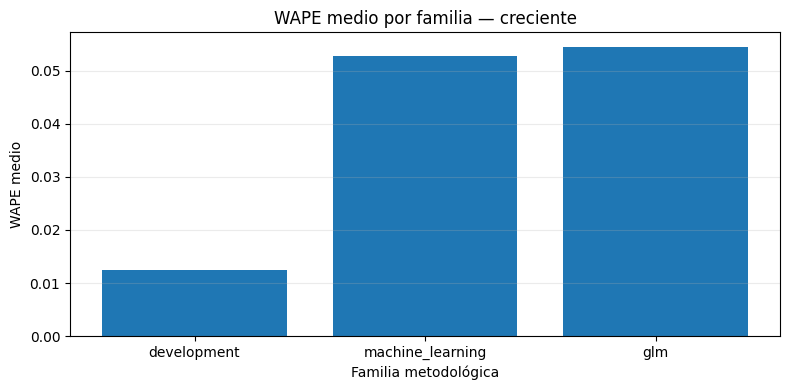

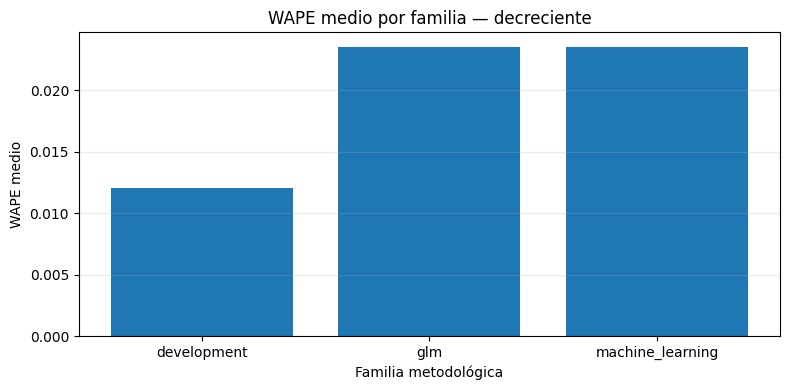

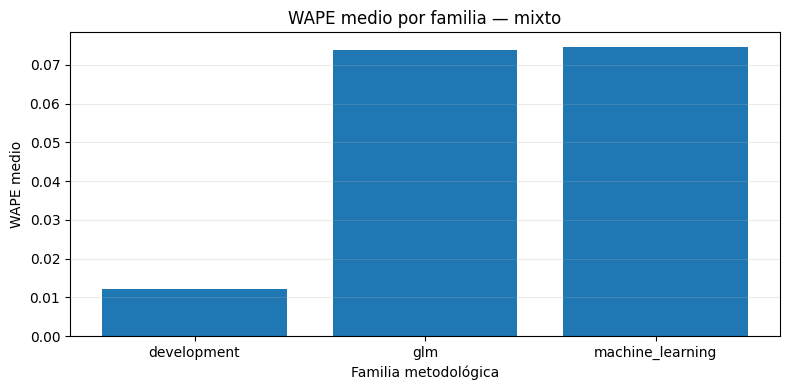

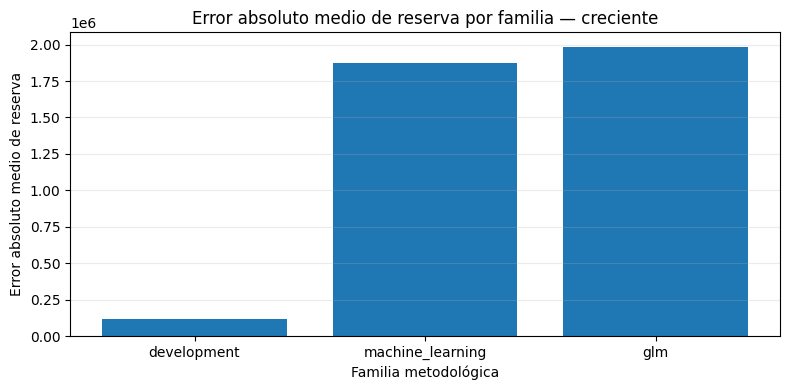

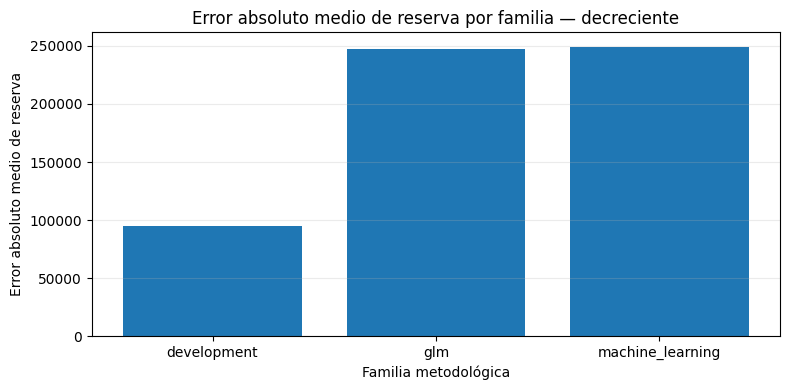

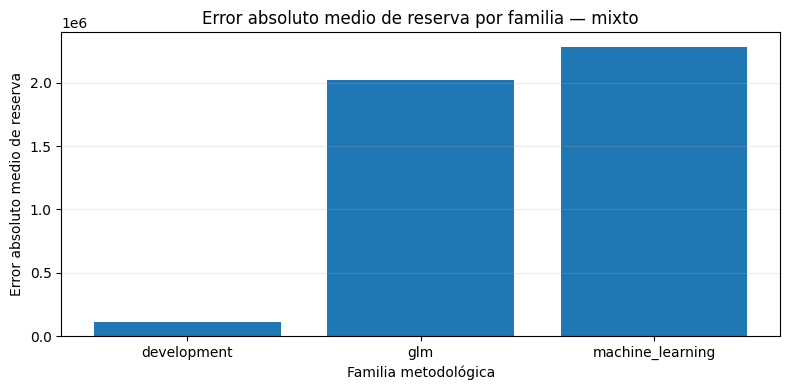

In [84]:
for metric, ylabel, title in [
    ("mean_wape", "WAPE medio", "WAPE medio por familia"),
    ("mean_abs_reserve_error", "Error absoluto medio de reserva", "Error absoluto medio de reserva por familia"),
]:
    for scenario in ["creciente", "decreciente", "mixto"]:
        plot_data = (
            reserve_summary[reserve_summary["scenario"] == scenario]
            .sort_values(metric)
        )

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(plot_data["method_family"], plot_data[metric])
        ax.set_title(f"{title} — {scenario}")
        ax.set_xlabel("Familia metodológica")
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()


## 9. Selección preliminar integrada

La selección final integra tres dimensiones del desempeño:

1. **Precisión global**, evaluada principalmente mediante MAE y complementada
   con RMSE y MAPE.
2. **Sesgo**, para verificar que el buen desempeño no provenga de errores
   sistemáticos de sobreestimación o subestimación.
3. **Estabilidad temporal**, evaluada mediante la distribución del MAE entre
   valuaciones históricas y la frecuencia con la que cada candidato obtiene
   el menor error.

Los resultados muestran una conclusión consistente en los tres escenarios.

La especificación de Desarrollo `VW_all_none` presenta el menor MAE global y
supera al mejor representante de GLM y Machine Learning en cada una de las
71 valuaciones históricas de los escenarios creciente, decreciente y mixto.

Además, mantiene un sesgo relativo cercano a cero y una variabilidad temporal
considerablemente menor que las alternativas predictivas en los escenarios
donde las diferencias de desempeño son mayores.

Por tanto, `VW_all_none` se selecciona como modelo final para los tres
escenarios considerados.

### Tabla de selección


In [85]:
selected_models = (
    family_candidates[
        family_candidates["method_family"]
        == "development"
    ]
    [
        [
            "scenario",
            "method_family",
            "method_name",
            "mae",
            "rmse",
            "mape",
            "bias",
            "relative_bias",
        ]
    ]
    .copy()
)

selected_models = selected_models.merge(
    stability_summary[
        [
            "scenario",
            "method_name",
            "std_mae",
            "cv_mae",
            "max_mae",
            "max_abs_relative_bias",
        ]
    ],
    on=["scenario", "method_name"],
    how="left",
    validate="one_to_one",
)

selected_models = selected_models.merge(
    winner_frequency[
        [
            "scenario",
            "method_name",
            "n_wins",
            "win_pct",
        ]
    ],
    on=["scenario", "method_name"],
    how="left",
    validate="one_to_one",
)

display(selected_models)

,scenario,method_family,method_name,mae,rmse,mape,bias,relative_bias,std_mae,cv_mae,max_mae,max_abs_relative_bias,n_wins,win_pct
0,creciente,development,VW_all_none,15384.030001,19484.983876,0.012463,155.155935,0.000126,1679.029393,0.109141,18980.599372,0.004620,71,100.0
1,decreciente,development,VW_all_none,15177.160022,19230.339915,0.012043,-538.223186,-0.000428,1937.809774,0.127679,19054.553288,0.004676,71,100.0
2,mixto,development,VW_all_none,15519.108462,19550.051073,0.012216,-83.383930,-0.000066,1980.627581,0.127625,21089.810442,0.004339,71,100.0


### Interpretación

La selección de `VW_all_none` es consistente en los tres escenarios, aunque la
magnitud de su ventaja depende del patrón de desarrollo.

#### Escenario creciente

`VW_all_none` alcanza un MAE aproximado de **15.4 mil**, frente a **63.4 mil**
del mejor modelo de Machine Learning y **65.4 mil** del mejor GLM.

Además de presentar menor error, el método de Desarrollo muestra una estabilidad
temporal sustancialmente mayor. Su coeficiente de variación del MAE es cercano
a 0.11, mientras que las alternativas GLM y ML presentan una elevada
variabilidad y algunas valuaciones con errores extremos.

#### Escenario decreciente

La diferencia entre familias se reduce. `VW_all_none` obtiene un MAE aproximado
de **15.2 mil**, mientras que GLM y Machine Learning se sitúan alrededor de
**29.5 mil**.

Aun cuando las tres familias presentan mayor estabilidad en este escenario,
`VW_all_none` obtiene el menor MAE en las 71 valuaciones históricas.

#### Escenario mixto

La separación vuelve a ser considerable. `VW_all_none` presenta un MAE cercano
a **15.5 mil**, frente a aproximadamente **92.4 mil** para GLM y **93.4 mil**
para Machine Learning.

Las alternativas predictivas muestran además mayor dispersión temporal y una
tendencia más marcada hacia la subestimación, mientras que el método de
Desarrollo mantiene un sesgo relativo agregado prácticamente nulo.

En conjunto, la evidencia favorece de forma consistente a `VW_all_none` dentro
del experimento realizado.

### Interpretación metodológica

El resultado anterior no debe interpretarse como evidencia de que los métodos
de Desarrollo sean, en general, superiores a GLM o Machine Learning.

Las bases utilizadas en este proyecto son simuladas y fueron construidas a
partir de patrones explícitos de desarrollo. En este contexto, los métodos de
Desarrollo poseen una ventaja estructural: utilizan directamente el monto
observado de cada cohorte y estiman el desarrollo restante mediante relaciones
edad-a-edad.

Los modelos GLM y Machine Learning, en cambio, deben aprender la relación entre
el monto observado, la edad de desarrollo, el período de ocurrencia y el monto
final a partir de las cohortes históricas disponibles.

Los resultados muestran que GLM y Machine Learning permanecen razonablemente
centrados en términos agregados en varios casos, pero presentan una dispersión
considerablemente mayor a nivel de cohorte. Esto explica que puedan mostrar un
sesgo global relativamente pequeño al mismo tiempo que registran MAE y RMSE
elevados.

Por tanto, la conclusión apropiada es específica al experimento:

> Bajo el proceso generador simulado, las variables disponibles y el protocolo
> de backtesting utilizado, la especificación de Desarrollo `VW_all_none`
> captura con mayor precisión y estabilidad la estructura del Loss Incurred que
> las alternativas GLM y Machine Learning evaluadas.

Este resultado ilustra que una mayor complejidad algorítmica no garantiza una
mejora predictiva cuando un modelo especializado representa adecuadamente la
estructura del fenómeno analizado.

## 10. Evaluación integral de los métodos

El requisito de evaluación considera conjuntamente precisión, sesgo, error de
reserva, estabilidad temporal, razonabilidad actuarial e interpretabilidad.

Los resultados obtenidos permiten resumir la comparación de la siguiente forma:

| Criterio | Desarrollo (`VW_all_none`) | GLM | Machine Learning |
|---|---|---|---|
| WAPE | Menor en los tres escenarios | Mayor | Mayor |
| RMSE | Menor en los tres escenarios | Mayor | Mayor |
| Sesgo | Cercano a cero y estable | Variable según escenario | Variable según escenario |
| Error de reserva | Menor error absoluto | Mayor | Mayor |
| Estabilidad temporal | Alta; menor MAE en las 71 valuaciones | Menor estabilidad | Menor estabilidad |
| Factores | Directamente vinculados al patrón de desarrollo | No utiliza factores edad-a-edad explícitos | No utiliza factores edad-a-edad explícitos |
| Interpretabilidad | Alta | Alta/moderada | Dependiente del algoritmo |

En el escenario mixto, el error relativo de reserva requiere una consideración
adicional. Debido a que el patrón combina desarrollos positivos y negativos, la
reserva neta real puede aproximarse a cero por compensación entre cohortes.
En consecuencia, dividir el error de reserva entre esta cantidad genera ratios
extremos e inestables.

Por esta razón, para el escenario mixto se priorizan el error absoluto de
reserva, WAPE, RMSE y sesgo sobre el error relativo de reserva.

### Razonabilidad actuarial de los factores

La especificación `VW_all_none` conserva una interpretación actuarial directa:
el monto observado de cada cohorte se proyecta hacia `dev_M` mediante factores
estimados a partir del desarrollo histórico disponible.

Esta estructura resulta especialmente apropiada para las bases simuladas del
experimento, ya que fueron construidas explícitamente a partir de patrones de
desarrollo.

En el escenario creciente, los factores reflejan principalmente desarrollo
positivo hacia el monto maduro. En el escenario decreciente representan los
ajustes posteriores esperados, mientras que en el escenario mixto capturan la
combinación de crecimiento inicial y ajustes posteriores.

La razonabilidad de estos patrones fue examinada previamente mediante los
triángulos y factores edad-a-edad. Por tanto, la superioridad predictiva de
`VW_all_none` es además consistente con la estructura actuarial utilizada para
generar los escenarios.

## 11. Selección del método preferido

A partir del backtesting y del razonamiento actuarial, se selecciona
`VW_all_none` como método preferido para los escenarios creciente, decreciente
y mixto.

La selección no depende únicamente de una métrica. En los tres escenarios,
`VW_all_none` presenta simultáneamente:

- el menor WAPE;
- el menor RMSE;
- sesgo agregado cercano a cero;
- menor error absoluto de reserva;
- mayor estabilidad entre fechas de valoración;
- el menor MAE en las 71 valuaciones históricas evaluadas;
- una estructura directamente interpretable mediante factores de desarrollo.

La magnitud de la ventaja no es idéntica entre escenarios. En el escenario
decreciente, GLM y Machine Learning se aproximan más al desempeño del método
de Desarrollo, mientras que en los escenarios creciente y mixto la diferencia
es considerablemente mayor.

Esta selección debe interpretarse dentro del diseño del experimento. Las bases
son simuladas y fueron construidas a partir de patrones explícitos de
desarrollo, por lo que un método especializado en explotar dicha estructura
posee una ventaja natural cuando el patrón histórico es estable.

Los resultados no implican que Desarrollo sea universalmente superior a GLM o
Machine Learning. La conclusión es que, bajo el proceso generador, las
variables disponibles y el protocolo de backtesting utilizados en este
experimento, `VW_all_none` proporciona las estimaciones más precisas, estables
e interpretables de las alternativas evaluadas.